In this project we use **MetaTrader 5** to collect **EURUSD** historical data in *1H* frame. Statistical analysis, visualisations, and forecasting utilizing *RandomForestRegressor* was performed. In addition the model was saved and trasformed to **ONNX** format, which can be load into **MQL5 EA** for a **automated trading system**. 

### Libraries

In [105]:
from datetime import datetime
import MetaTrader5 as mt5
import pandas as pd
import numpy as np
import pytz
import seaborn as sns
import matplotlib.pyplot as plt
import ta
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,r2_score
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType
import onnxruntime as rt

### Checking MetaTrader 5 Version

In [5]:
print("MetaTrader5 package author: ", mt5.__author__)
print("MetaTrader5 package version: ", mt5.__version__)

MetaTrader5 package author:  MetaQuotes Ltd.
MetaTrader5 package version:  5.0.5735


### Initialize MetaTrader Conecction

In [6]:
# Connection to MetaTrader 5 terminal
if not mt5.initialize():
    print("initialize() failed, error code =", mt5.last_error())
    quit()

### Set the time inverval

By default, Python relies on the system's local time when creating the datatime object. MetaTrider 5 stores tick and bar times in UTC format without reference to the local time zone creating a missmatch.

In [7]:
# Set time zone to UTC
timezone = pytz.timezone("Etc/UTC")
# Create 'datetime' objects in UTC time zone to avoid the implementation of a local time zone offset
utc_from = datetime(2020, 1, 1, tzinfo=timezone)
utc_to = datetime.now(timezone)  # Set to the current date and time

### Request for Historical Data

In [8]:
# Get bars from EURUSD H1 (hourly timeframe) within the specified interval
rates = mt5.copy_rates_range("EURUSD", mt5.TIMEFRAME_H1, utc_from, utc_to)

In [9]:
rates

array([(1577944800, 1.12132, 1.12143, 1.12008, 1.12011,  904, 1, 0),
       (1577948400, 1.12011, 1.12043, 1.12008, 1.12043,  683, 2, 0),
       (1577952000, 1.12043, 1.12075, 1.12037, 1.12066,  801, 1, 0), ...,
       (1778752800, 1.17182, 1.17184, 1.17053, 1.17075, 3542, 0, 0),
       (1778756400, 1.17074, 1.17138, 1.17042, 1.17109, 2969, 0, 0),
       (1778760000, 1.1711 , 1.17132, 1.17051, 1.1707 , 3275, 0, 0)],
      dtype=[('time', '<i8'), ('open', '<f8'), ('high', '<f8'), ('low', '<f8'), ('close', '<f8'), ('tick_volume', '<u8'), ('spread', '<i4'), ('real_volume', '<u8')])

### Shutdown Connection

In [10]:
# Shut down connection to the MetaTrader 5 terminal
mt5.shutdown()

True

### Checking Historical Data

In [12]:
# Check if data was retrieved
if rates is None or len(rates) == 0:
    print("No data retrieved. Please check the symbol or date range.")
    quit()
# Print the first 10 raw records for a quick data sanity check
print("Display obtained data 'as is'")
for rate in rates[:5]:
    print(rate)

Display obtained data 'as is'
(1577944800, 1.12132, 1.12143, 1.12008, 1.12011, 904, 1, 0)
(1577948400, 1.12011, 1.12043, 1.12008, 1.12043, 683, 2, 0)
(1577952000, 1.12043, 1.12075, 1.12037, 1.12066, 801, 1, 0)
(1577955600, 1.12074, 1.12102, 1.12043, 1.12098, 1721, 1, 0)
(1577959200, 1.12098, 1.12136, 1.12052, 1.12118, 1833, 1, 0)


### Data Visualisation

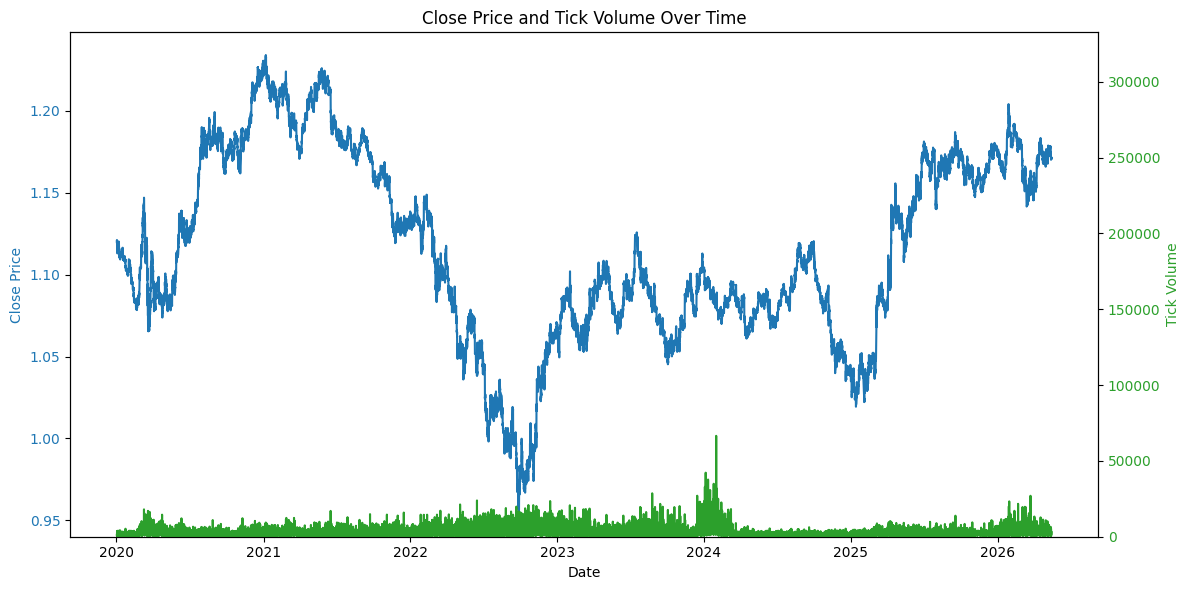

In [16]:
# Create a DataFrame from the retrieved tick data
rates_frame = pd.DataFrame(rates)
# Convert the timestamp column from seconds since epoch to datetime
rates_frame['time'] = pd.to_datetime(rates_frame['time'], unit='s')

# Use datetime as the DataFrame index for time series plotting and analysis
rates_frame.set_index('time', inplace=True)

# Plot closing price and tick volume
fig, ax1 = plt.subplots(figsize=(12, 6))

# Close price on primary y-axis
ax1.set_xlabel('Date')
ax1.set_ylabel('Close Price', color='tab:blue')
ax1.plot(rates_frame.index, rates_frame['close'], color='tab:blue', label='Close Price')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Tick volume on secondary y-axis
ax2 = ax1.twinx()  
ax2.set_ylabel('Tick Volume', color='tab:green')
max_tick = rates_frame['tick_volume'].max()
ax2.set_ylim(0, max_tick * 5)
ax2.plot(rates_frame.index, rates_frame['tick_volume'], color='tab:green', label='Tick Volume')
ax2.tick_params(axis='y', labelcolor='tab:green')

# Show the plot
plt.title('Close Price and Tick Volume Over Time')
fig.tight_layout()
plt.show()
#fig.savefig('close_price.png')

### Testing Hypothesis

Hypothesis: The market tends to continue the movement of the last bar.

In [17]:
# Correlation analysis between adjacent bar moves
close = rates_frame['close'].to_numpy(dtype=float)
# last and next price move differences
diff = close[1:] - close[:-1]

In [18]:
# Two time series: last and next changes
diff = np.column_stack((diff[:-1], diff[1:]))
data_matrix = pd.DataFrame(diff, columns=['last', 'next'])

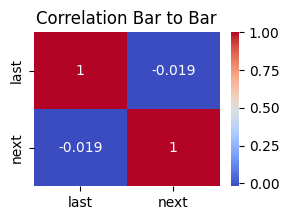

In [19]:
correlation_matrix = data_matrix.corr('pearson')
plt.subplots(figsize=(3, 2))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Bar to Bar') 
plt.savefig('bar_to_bar.png')
plt.show()

Results:

- The observed correlation is -0.019, value close to zero with a negative sign.
This means that there is no clear relationship between adjacent bars.

- The hypothesis of movement of continuation is not confirmed. The market on the H! timeframe behaves closer to a random process than to an inertial system.

### Cheking averanges from 1 to 23 bars

One candle is too small a scale. Therefore, we enlarge the observations, and not check individual changes, but averanges movements.

Instead of a single bar, we take the price change over a historical interval from 1 to 23 bars. Similarly, we form the future averange price change on the horizon from 1 to 9 bars.

#### The imprementation is neatly devided into two blocks.

First, calculate moving averanges for past changes

In [20]:
# Add rolling mean features for the previous and future moves
for period in range(2, 24, 1):
    data_matrix[f'last_mean_{period:02d}'] = data_matrix['last'].rolling(window=period).mean()

Secondly, Calculate moving averanges for the future changes, with a shift to prevent information leakage

In [21]:
for period in range(2, 10, 1):
    data_matrix[f'next_mean_{period}'] = data_matrix['next'].rolling(window=period).mean().shift(-(period-1))

After calculations, removing rows with missing values.

In [22]:
# Remove rows with missing values created by rolling calculations
data_matrix.dropna(inplace=True)

In [23]:
data_matrix.head()

,last,next,last_mean_02,last_mean_03,last_mean_04,last_mean_05,last_mean_06,last_mean_07,last_mean_08,last_mean_09,...,last_mean_22,last_mean_23,next_mean_2,next_mean_3,next_mean_4,next_mean_5,next_mean_6,next_mean_7,next_mean_8,next_mean_9
22,-0.00004,-0.00022,-0.000075,-0.000110,0.000032,0.000018,-0.000002,0.000041,0.000074,0.000022,...,-0.000146,-0.000126,-0.000290,-0.000103,-0.000475,-0.000420,-0.000535,-0.000517,-0.000529,-0.000368
23,-0.00022,-0.00036,-0.000130,-0.000123,-0.000138,-0.000018,-0.000022,-0.000033,0.000009,0.000041,...,-0.000167,-0.000150,-0.000045,-0.000560,-0.000470,-0.000598,-0.000567,-0.000573,-0.000386,-0.000352
24,-0.00036,0.00027,-0.000290,-0.000207,-0.000182,-0.000182,-0.000075,-0.000070,-0.000074,-0.000032,...,-0.000198,-0.000175,-0.000660,-0.000507,-0.000657,-0.000608,-0.000608,-0.000390,-0.000351,-0.000157
25,0.00027,-0.00159,-0.000045,-0.000103,-0.000088,-0.000092,-0.000107,-0.000026,-0.000027,-0.000036,...,-0.000195,-0.000177,-0.000895,-0.000967,-0.000827,-0.000784,-0.000500,-0.000440,-0.000210,-0.000062
26,-0.00159,-0.00020,-0.000660,-0.000560,-0.000475,-0.000388,-0.000342,-0.000319,-0.000221,-0.000201,...,-0.000226,-0.000255,-0.000655,-0.000573,-0.000582,-0.000282,-0.000248,-0.000013,0.000129,0.000209


### The Pearson correlation matrix

Next, the Pearson correlation matrix is constructed, and the secessary submatrix is retreived form it, **dependence of the future from the past**.

Here is the answer to the main question: **does the averange movement have predictive power?**

In [24]:
correlation_matrix = data_matrix.corr('pearson')
# Match columns that begin with "next"
reg = r'^next.*$'
selected_cols = correlation_matrix.filter(regex=reg).columns
remaining_rows = correlation_matrix.index.difference(selected_cols)
correlation_matrix = correlation_matrix.loc[remaining_rows, selected_cols]

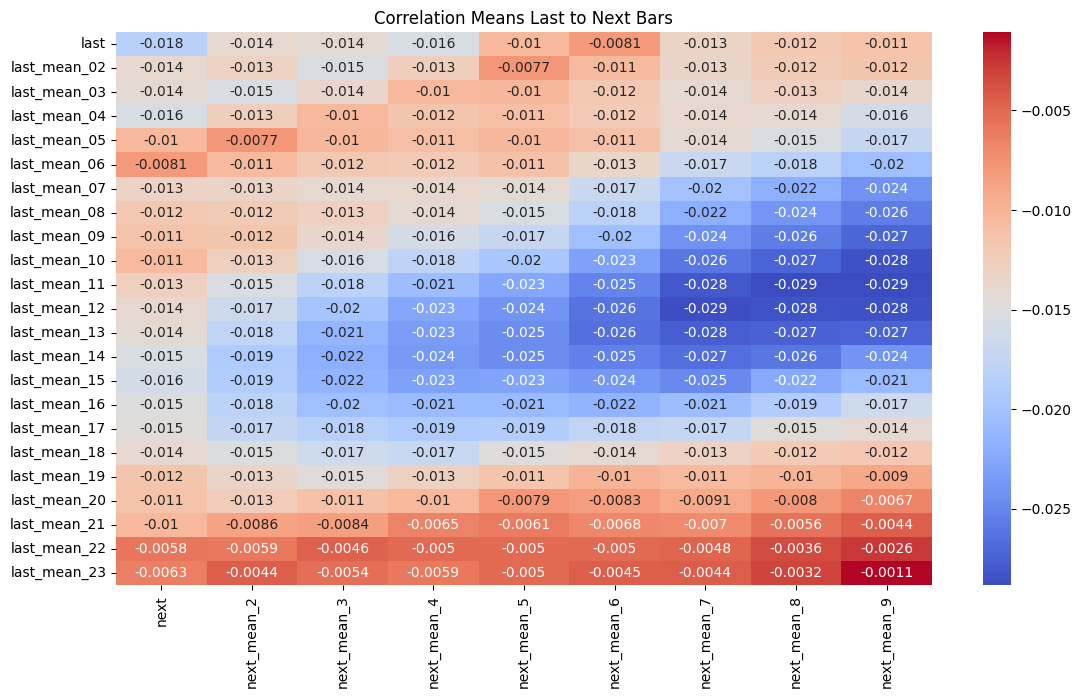

In [25]:
plt.figure(figsize=(12, 7))
plt.subplots_adjust(left=0.15, right=1, bottom=0.16, top=0.95)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Means Last to Next Bars') 
#plt.savefig('mean_to_bar.png')
plt.show()

**Results:**

- We still see negative correlation values.
- In the central-right region of the matrix ( windows 7-15 bars in history and 5-8 bas in the horizon), the effect intesifies and reaches values of -0.02...0.03. This is a weak but consistent mean reversion signal.

The conclusion is traightforward: the market does not exhibit strong inertia, but it does show a weak mean-reversion effect.

Since the obtained correlation values are low, such signal cannot be scaled directly into trading in a linear setting. If a simply relationshio is weak, we can try to strengthen it through a combination of features.

### Indicators

The next step is to seek for additional features that can capture the hidden structure of the market. It makes sense to use classic technical indicators as a basic set. This is a time-tested tool that, despite of its simplicitym often provides useful signals.

In the code, this approach is implemented quite systematically. On the one hand, simple derivatives of the price are used - moving averanges, their first and second differences, deviations from the current values.

In [26]:
# Recreate the base matrix for indicator engineering
data_matrix = pd.DataFrame(diff, columns=['last', 'next'])

# Add 11-period previous move averanges and derived momentum features
data_matrix[f'last_mean_11'] = data_matrix['last'].rolling(window=11).mean()
data_matrix[f'Dlast_mean_11'] = data_matrix[f'last_mean_11'].diff()
data_matrix[f'DDlast_mean_11'] = data_matrix[f'Dlast_mean_11'].diff()

# Feature representing the gap between the rolling mean and the current move
data_matrix[f'last_last_11'] = data_matrix[f'last_mean_11'] - data_matrix['last']
data_matrix[f'Dlast_last_11'] = data_matrix[f'last_last_11'].diff()
data_matrix[f'DDlast_last_11'] = data_matrix[f'Dlast_last_11'].diff()

# Add short-term future sum targets for the next bars
for period in range(2, 10, 1):
    data_matrix[f'next_{period}'] = data_matrix['next'].rolling(window=period).sum().shift(-(period-1))

On the other hand, classic indicators from the *TA library* as added: SMA, RSI, MACD, moreover in several parameterizations at once.

In [27]:
# Build additional technical indicators using the close price series
close = pd.DataFrame(close[:-1], columns=['close'])
indicator_cols = {}
for period in [4, 8, 12, 24, 36, 48]:
    sma= ta.trend.sma_indicator(close['close'], window=period, fillna=True)
    dsma= sma.diff()
    ddsma= dsma.diff()
    rsi = ta.momentum.rsi(close['close'], window=period, fillna=True)
    drsi = rsi.diff()
    ddrsi=drsi.diff()
    macd = ta.trend.MACD(
        close['close'], window_slow=2 * period,
        window_fast=period,
        window_sign= period * 3//4,
        fillna=True
    )
    macd_main= macd.macd()
    dmacd=macd_main.diff()
    ddmacd=dmacd.diff()
    macd_diff = macd.macd_diff()
    dmacd_diff = macd_diff.diff()
    ddmacd_diff = dmacd_diff.diff()
    macd_signal=macd.macd_signal()
    dmacd_signal = macd_signal.diff()
    ddmacd_signal = dmacd_signal.diff()
    macd_sig_main = macd_signal - macd_main
    dmacd_sig_main = macd_sig_main.diff()
    ddmacd_sig_main = dmacd_sig_main.diff()

    indicator_cols[f'SMA_{period:02d}'] = sma
    indicator_cols[f'DSMA_{period:02d}'] = dsma
    indicator_cols[f'DDSMA_{period:02d}'] = ddsma
    indicator_cols[f'RSI_{period:02d}'] = rsi
    indicator_cols[f'DRSI_{period:02d}'] = drsi
    indicator_cols[f'DDRSI_{period:02d}'] = ddrsi
    indicator_cols[f'MACD_{period:02d},{2*period:02d},{period*3//4:02d}'] = macd_main
    indicator_cols[f'DMACD_{period:02d},{2*period:02d},{period*3//4:02d}'] = dmacd
    indicator_cols[f'DDMACD_{period:02d},{2*period:02d},{period*3//4:02d}'] = ddmacd
    indicator_cols[f'MACD_DIFF_{period:02d},{2*period:02d},{period*3//4:02d}'] = macd_diff
    indicator_cols[f'DMACD_DIFF_{period:02d},{2*period:02d},{period*3//4:02d}'] = dmacd_diff
    indicator_cols[f'DDMACD_DIFF_{period:02d},{2*period:02d},{period*3//4:02d}'] = ddmacd_diff
    indicator_cols[f'MACD_SIGNAL_{period:02d},{2*period:02d},{period*3//4:02d}'] = macd_signal
    indicator_cols[f'DMACD_SIGNAL_{period:02d},{2*period:02d},{period*3//4:02d}'] = dmacd_signal
    indicator_cols[f'DDMACD_SIGNAL_{period:02d},{2*period:02d},{period*3//4:02d}'] = ddmacd_signal
    indicator_cols[f'MACD_Sig_Main{period:02d},{2*period:02d},{period*3//4:02d}'] = macd_sig_main
    indicator_cols[f'DMACD_Sig_Main{period:02d},{2*period:02d},{period*3//4:02d}'] = dmacd_sig_main
    indicator_cols[f'DDMACD_Sig_Main{period:02d},{2*period:02d},{period*3//4:02d}'] = ddmacd_sig_main
# Append all indicator columns to the feature matrix in one operation
# This avoids repeated Dataframe assigment and keeps the DataFrame compact

data_matrix = pd.concat([data_matrix, pd.DataFrame(indicator_cols)], axis=1)

# Remove any rows wit NaN values
data_matrix.dropna(inplace=True)

The addition of second-order derivatives is especially indicative (diff and diff from diff). This is already an attempt to capture the change in the signal itself - a transition to the analysis of the acceleration and decelaration of market movement.

In [28]:
data_matrix.head()

,last,next,last_mean_11,Dlast_mean_11,DDlast_mean_11,last_last_11,Dlast_last_11,DDlast_last_11,next_2,next_3,...,"DDMACD_48,96,36","MACD_DIFF_48,96,36","DMACD_DIFF_48,96,36","DDMACD_DIFF_48,96,36","MACD_SIGNAL_48,96,36","DMACD_SIGNAL_48,96,36","DDMACD_SIGNAL_48,96,36","MACD_Sig_Main48,96,36","DMACD_Sig_Main48,96,36","DDMACD_Sig_Main48,96,36"
12,0.00036,0.00003,-0.000335,0.000012,0.000352,-0.000695,-0.003768,-0.009498,-0.00036,-0.00006,...,-0.000069,-0.000128,-0.000059,-0.000066,-0.000008,-0.000007,-0.000003,0.000128,0.000059,0.000066
13,0.00003,-0.00039,-0.000361,-0.000026,-0.000038,-0.000391,0.000304,0.004072,-0.00009,0.00021,...,0.000011,-0.000173,-0.000045,0.000014,-0.000018,-0.000010,-0.000003,0.000173,0.000045,-0.000014
14,-0.00039,0.00030,-0.000415,-0.000054,-0.000027,-0.000025,0.000366,0.000063,0.00060,0.00050,...,0.000004,-0.000212,-0.000039,0.000006,-0.000030,-0.000012,-0.000002,0.000212,0.000039,-0.000006
15,0.00030,0.00030,-0.000306,0.000108,0.000162,-0.000606,-0.000582,-0.000948,0.00020,0.00016,...,-0.000005,-0.000253,-0.000041,-0.000002,-0.000044,-0.000014,-0.000002,0.000253,0.000041,0.000002
16,0.00030,-0.00010,-0.000236,0.000070,-0.000038,-0.000536,0.000070,0.000652,-0.00014,0.00032,...,0.000010,-0.000282,-0.000030,0.000011,-0.000060,-0.000016,-0.000002,0.000282,0.000030,-0.000011


Next, filtering is applied. From the entire correlation matrix, onthe the features whose maximum relationship with the target variable exceeds the specific threshold( in this calse, 0.02) remain.

In [29]:
correlation_matrix = data_matrix.corr('pearson')
selected_cols = correlation_matrix.filter(regex=reg).columns
remaining_rows = correlation_matrix.index.difference(selected_cols)
correlation_matrix = correlation_matrix.loc[remaining_rows, selected_cols]

#Delete rows with low correlation
correlation_matrix= correlation_matrix[correlation_matrix.abs().max(axis=1) >=0.02]

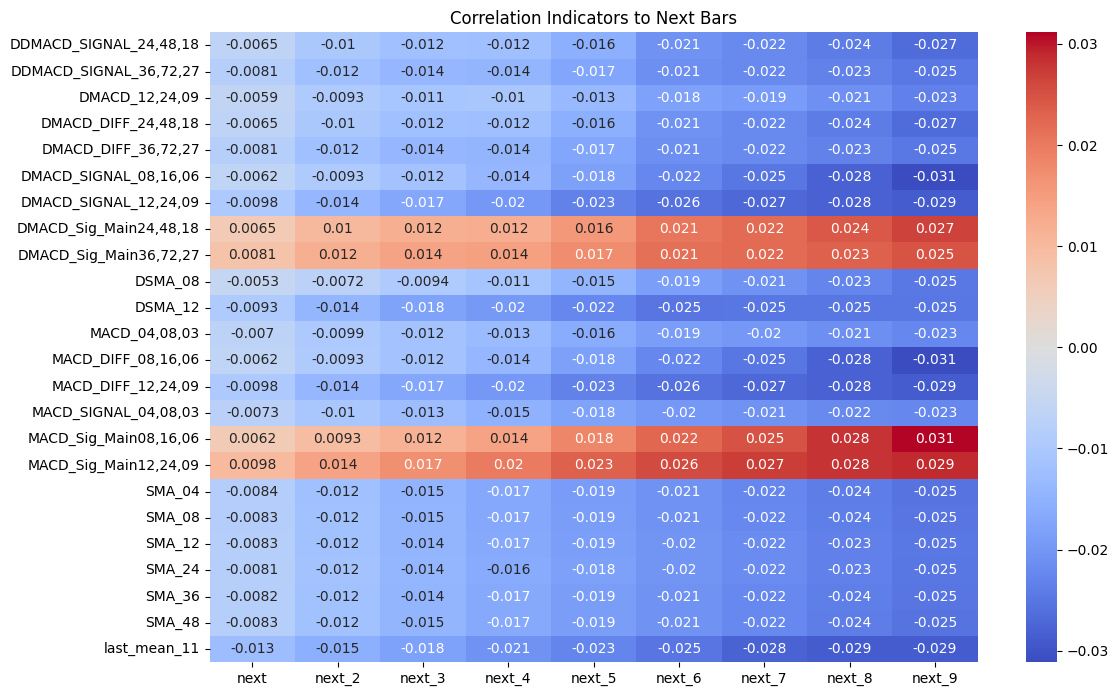

In [30]:
plt.figure(figsize=(12, 7))
plt.subplots_adjust(left=0.2, right=1, bottom=0.05, top=0.95)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Indicators to Next Bars') 
plt.savefig('trend_to_bar.png')
plt.show()

This is where the set of hypotheses begins to take on structure. We are moving from random selection of indicators to conscious formation of features. This is not a model yet, but rather its frame.

The next task is to assemble these weak, disparate signals into a single system capable of extracting s stalbe dependence where, individually, it is almost invisible.

### Building and Traning a Model

In the previous step, we obtained a correlation map and selected features, with the maximum values of direct and inverse correlation. This is a fundamental point: *negative correlation is the same signal, just with the oppositive sign.*

For this project we will use **RandomForestRegressor**. It works well with non-linear dependencies, is robust to noise, and does not require agressive data normalization.

The next key step is selecting hyperparameters. Let's use direct enumeration by two parameters: number of trees(n_estimators), and tree deph (max_depth). The first parameter is responsible for the ensemble strength, while the second one focuses on the degree of immersion of an individual tree into the data and control over overfitting.

A basic matrix is contrsucted: Price differences, their smoothed versions and derived features.

In [34]:
# Optional we can create a new script, just coneccting to MetaTrader5 and,
# loading historical price data.
rates_frame.head()

,open,high,low,close,tick_volume,spread,real_volume
time,,,,,,,
2020-01-02 06:00:00,1.12132,1.12143,1.12008,1.12011,904,1,0
2020-01-02 07:00:00,1.12011,1.12043,1.12008,1.12043,683,2,0
2020-01-02 08:00:00,1.12043,1.12075,1.12037,1.12066,801,1,0
2020-01-02 09:00:00,1.12074,1.12102,1.12043,1.12098,1721,1,0
2020-01-02 10:00:00,1.12098,1.12136,1.12052,1.12118,1833,1,0


In [39]:
macd_settings= [(8,16,6),(12,24,9),(36,72,27),(48,96,36)]
features= []

# Build the base feature matrix from close price changes
close= pd.DataFrame(rates_frame['close'][:-1].to_numpy(dtype=float), columns=['close'])
diff = rates_frame['close'].diff().to_numpy(dtype=float)

#pair consecutive differences into 'last' and 'next' comlumns
diff = np.column_stack((diff[:-1], diff[1:]))
data_matrix = pd.DataFrame(diff, columns=['last','next'])
features.append('last') # add to features list for later use

# Add a 11-period rolling mean of the previous bar move
data_matrix['last_11'] = data_matrix['last'].rolling(window=11).mean()
features.append('last_11') # Add to features list for later use

# Add the differences between to rolling mean and current bar move
data_matrix['last_last_11']= data_matrix['last_11'] - data_matrix['last']
features.append('last_last_11') # add to features list for later use

Next, technical indicators are added: *SMA* and a set of *MACD* configurations.

In [40]:
# Add a 12-period simple moving average as a technical features
data_matrix['SMA_12'] = ta.trend.sma_indicator(close['close'], window=12, fillna=True)
features.append('SMA_12') # Add to features list for later use

# Add MACD-based technical indicators for the selected parameter sets
for fast, slow, sign in macd_settings:
    macd = ta.trend.MACD(
        close['close'],
        window_slow=slow,
        window_fast=fast,
         window_sign=sign,
        fillna=True,)
    macd_main = macd.macd()
    dmacd = macd_main.diff()
    macd_signal = macd.macd_signal()
    dmacd_signal = macd_signal.diff()
    macd_sig_main = macd_signal - macd_main

    sufix = f"{fast:02d},{slow:02d},{sign:02d}"
    data_matrix[f'MACD_MAIN_{sufix}'] = macd_main
    features.append(f'MACD_MAIN_{sufix}') # Add to features list for later use
    data_matrix[f'DMACD_MAIN_{sufix}'] = dmacd
    features.append(f'DMACD_MAIN_{sufix}') # Add to features list for later use
    data_matrix[f'MACD_SIGNAL_{sufix}'] = macd_signal
    features.append(f'MACD_SIGNAL_{sufix}') # Add to features list for later use
    data_matrix[f'DMACD_SIGNAL_{sufix}'] = dmacd_signal
    features.append(f'DMACD_SIGNAL_{sufix}') # Add to features list for later use
    data_matrix[f'MACD_Sig_Main_{sufix}'] = macd_sig_main
    features.append(f'MACD_Sig_Main_{sufix}') # Add to features list for later use
    data_matrix[f'DMACD_Sig_Main_{sufix}'] = macd_sig_main.diff()
    features.append(f'DMACD_Sig_Main_{sufix}') # Add to features list for later use

All features are sequentially accumulated in a single data structure, while their names are set in a separate features list. This simplifies work, and eliminates accidental loss of variables.

At this steo, **The Target Variable** is formed ( the total price movement over a given horizon next_9).

In [41]:
# Add a 0-period future return target for the nex bars
data_matrix['next_9'] = data_matrix['next'].rolling(window=9).sum().shift(-8)

Thus, the problem is formalized as a regression: based on current indicators, predict future price changes.

Next step is data cleaning. After applying sliding windows and differentiation, missing values inevitably appear.

In [43]:
data_matrix.dropna(inplace=True)

Next, the data is divided by time: the first 90% is used for training, and the remaining 10% for testing.

### Data Preparation

In [44]:
# data preparation
# copy the raw feature matrix(preserving the oginal data for later reference)
df= data_matrix.copy()

# keep only features that are actually present in the DataFrame
features = [c for c in features if c in data_matrix.columns]

df = df[features + ['next_9']]
X = df[features]
y = df['next_9']

In [45]:
# Split data
split = int(len(X)*0.9)
X_train = X.iloc[:split]
X_test= X.iloc[split:]
y_train = y.iloc[:split]
y_test= y.iloc[split:]

### Model Training

After this, a cycle of enumeration of the *RandomForestRegressor* model hyperparameters is launched. For each combination of parameters, a full cycle is performed.

The model is trained on a trainig sample;

In [74]:
# ===== Model =====
results=[]

for est in range(60, 111,5):
    for dep in range(2,14,1):
        print(f'\n=== Extimators: {est}, Max Depth: {dep} ===')
        model = RandomForestRegressor(
            n_estimators = est,
            max_depth = dep,
            max_leaf_nodes = None,
            min_samples_split=6,
            min_samples_leaf=3,
            bootstrap=True,
            random_state=42,
            n_jobs=-1
        )
        model.fit(X_train,y_train)
        
        # ===== Evaluation =====
        #builds forecasts for the training and test parts, 
        #the results are brought to a stable form (handling NaN and infinities);
        pred_train=np.nan_to_num(model.predict(X_train), nan=0.0, posinf=0.0, neginf=0.0)
        pred_test = np.nan_to_num(model.predict(X_test), nan=0.0, posinf=0.0, neginf=0.0)
       #Quality metrics are calculated
        pt_corr = np.corrcoef(pred_test, y_test)[0, 1]
        results.append((est, dep, pt_corr))
        print("Train R2:", round(r2_score(y_train, pred_train), 6))
        print("Test  R2:", round(r2_score(y_test, pred_test), 6))
        print("Test MAE:", round(mean_absolute_error(y_test, pred_test), 8))
        print("Pred/Target corr:", round(pt_corr, 6))


=== Extimators: 60, Max Depth: 2 ===
Train R2: 0.0095
Test  R2: -0.002329
Test MAE: 0.00190098
Pred/Target corr: -0.064034

=== Extimators: 60, Max Depth: 3 ===
Train R2: 0.015993
Test  R2: -0.004605
Test MAE: 0.0019021
Pred/Target corr: -0.075597

=== Extimators: 60, Max Depth: 4 ===
Train R2: 0.026411
Test  R2: -0.00757
Test MAE: 0.0019039
Pred/Target corr: -0.103104

=== Extimators: 60, Max Depth: 5 ===
Train R2: 0.038351
Test  R2: -0.00946
Test MAE: 0.00190446
Pred/Target corr: -0.091881

=== Extimators: 60, Max Depth: 6 ===
Train R2: 0.052693
Test  R2: -0.011135
Test MAE: 0.00190543
Pred/Target corr: -0.083021

=== Extimators: 60, Max Depth: 7 ===
Train R2: 0.068585
Test  R2: -0.014657
Test MAE: 0.00190788
Pred/Target corr: -0.096464

=== Extimators: 60, Max Depth: 8 ===
Train R2: 0.085679
Test  R2: -0.01813
Test MAE: 0.00191095
Pred/Target corr: -0.103531

=== Extimators: 60, Max Depth: 9 ===
Train R2: 0.105156
Test  R2: -0.01841
Test MAE: 0.00191229
Pred/Target corr: -0.089334


The Key metric is the correlation between the forecast and the actual value on the test sample. It is this that reclects the model ability to capture the movement direction. R2 and MAE are additionally calculated to control the overall quality of the approximation and the error level.

All results as stored in a table, each row of which corresponds to a specific combination of hyperparameters. Next, this table is converted into a matrix form, which allows us to visualize the dependence of the model quality on the parameters.

In [75]:
# Results
df_results= pd.DataFrame(
    results, columns=['Estimator', 'Max Depth', 'Test Correlation']
)


In [78]:
# --- pivot table ---
heatmap_data = df_results.pivot(
    index="Estimator",
    columns="Max Depth",
    values="Test Correlation"
).sort_index()

Final step is visualisation by meas. The heatmap clearly shows, in which parameter area the best results are achieved.

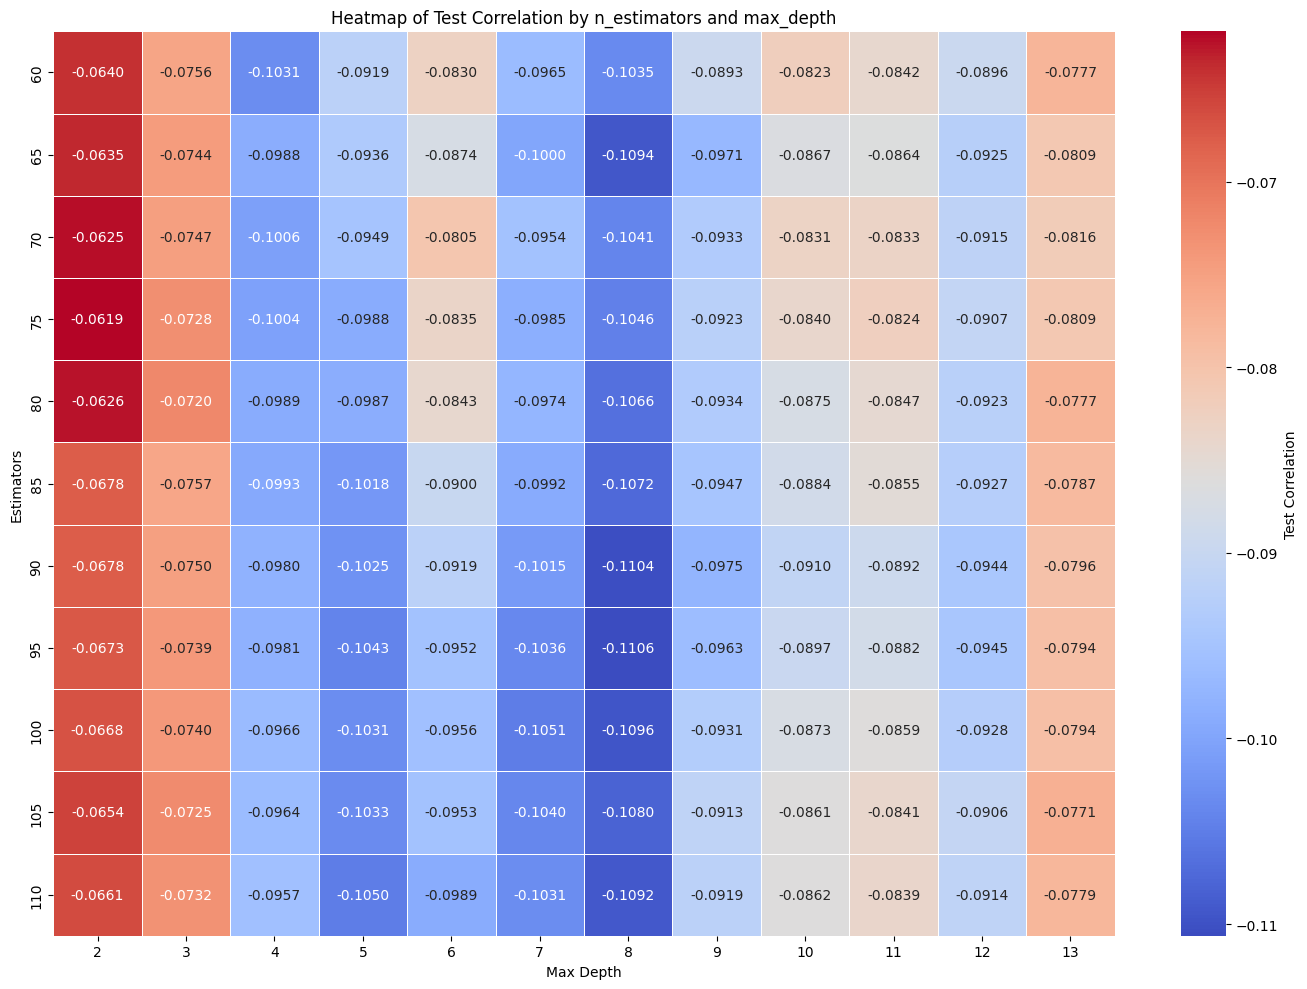

In [81]:
# heatmap
plt.figure(figsize=(14,10))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.4f',
    cmap="coolwarm",
    linewidths=0.5,
    cbar_kws={'label':'Test Correlation'}
)
plt.title('Heatmap of Test Correlation by n_estimators and max_depth')
plt.xlabel('Max Depth')
plt.ylabel('Estimators')
plt.tight_layout()
plt.show()

Next, the model is not equally confident across its forecasts. In some cases it gives a strong signal, in others the values are colse to zero and are actually in the zone of uncertainty.

This leads to a natural hypotesis: ignore weak signals and work only where the model demonstrates sufficient confidence or the expected movement covers the costs.

In [82]:
# ===== 5) Simple PnL prototype =====
# Calculate strategy metrics for a vector of thresholds without an explicit loop
percentiles = np.arange(10, 100, 5)
thresholds = np.percentile(np.abs(pred_train), percentiles)

Next, a matrix of forecasts and corresponding thresholds is formed.

In [84]:
# Build a matrix where each column repeats the test predictions
pred_matrix = np.tile(pred_test[:, None], (1, thresholds.size))
threshold_matrix = thresholds[None, :]

# Generate a mask per threshold and compute sign positions
mask = np.abs(pred_matrix) >= threshold_matrix
position = np.sign(pred_matrix) * np.sign(pt_corr) * mask.astype(float)

After this, the profitability is formed as the product of the position and the actual movement. Fixed costs (spread/commission) are subtracted and the cumulative capital curve is constructed.

In [93]:
# Broadcast y_check to match the threshold matrix shape
y_check=y_test
y_check_matrix = np.tile(y_check.values[:, None], (1, thresholds.size))
# Subtracting swap cost from the target to get a more realistic PnL estimate
strategy_ret = position * y_check_matrix - np.abs(position)*(0.00021)

# Compute equity curves for each threshold column
equity = np.cumsum(strategy_ret, axis=0)

The results are aggregated into a table:

- final_equity — final profitability;
- mean_return — average trade result;
- win_rate — share of profitable entries.

In [95]:
# Aggregate results into a DataFrame
results = pd.DataFrame({
    'percentile': percentiles,
    'threshold': thresholds,
    'final_equity': equity[-1, :],
    'mean_return': np.sum(strategy_ret, axis=0)/(np.sum(strategy_ret != 0, axis=0)+1e-9),
    'win_rate': np.sum(strategy_ret > 0, axis=0)/(np.sum(strategy_ret != 0, axis=0)+1e-9)
})

print(results.to_string(index=False, float_format='%.8f'))

 percentile  threshold  final_equity  mean_return   win_rate
         10 0.00000756   -0.37365000  -0.00011406 0.49755800
         15 0.00001128   -0.44019000  -0.00013974 0.49269841
         20 0.00001385   -0.49193000  -0.00018979 0.48341049
         25 0.00001729   -0.35079000  -0.00016833 0.49040307
         30 0.00002038   -0.31297000  -0.00017358 0.48252912
         35 0.00002837   -0.18256000  -0.00011613 0.48727735
         40 0.00004337   -0.08431000  -0.00005963 0.48797737
         45 0.00005742   -0.02742000  -0.00002215 0.49596123
         50 0.00007299   -0.01484000  -0.00001411 0.49239544
         55 0.00008764   -0.00814000  -0.00000816 0.49799599
         60 0.00010210    0.06202000   0.00006705 0.51243243
         65 0.00011791    0.08725000   0.00010145 0.51627907
         70 0.00013647    0.15140000   0.00024070 0.52941176
         75 0.00017366    0.21529000   0.00042297 0.55992141
         80 0.00025074    0.19790000   0.00051403 0.56103896
         85 0.00039140  

From a practical point of view, this is no longer just an assessment of a model, but the beginning of a trading system. We not only check the forecast accuracy, but also immediately assess how it is monetized at different sorting levels.

### Transformation to ONNX

The MetaTrader 5 platform offers two automation paths. The first one is launching the Python script with direct execution of trades. The second one is transferring the model into the ONNX format with subsequent use in the MQL5 EA.

The conversion is fairly straightforward. First, the input of the model is described — the dimension of the feature space.

In [96]:
# Number of features used for model input
n_features = X_train.shape[1]

# Describe the model input shape for ONNX conversion
initial_type = [("float_input", FloatTensorType([None, n_features]))]

Next, the trained model from Scikit-Learn is transformed into ONNX via the appropriate converter and saved to disk.

In [101]:
# Convert the trained sklearn model to ONNX format
onnx_model = convert_sklearn(model, initial_types=initial_type)
onnx_model_path=r"C:\Users\erick\model.onnx"
# Save the ONNX model to disk
with open(onnx_model_path, "wb") as f:
    f.write(onnx_model.SerializeToString())

The model is loaded via **ONNX Runtime**, and the same data are used to calculate predicted values.

In [106]:
# Load the ONNX model for inference
sess = rt.InferenceSession(onnx_model_path)

input_name = sess.get_inputs()[0].name

# ONNX runtime expects float32 input arrays
X_test_np = X_test.astype(np.float32).values

onnx_preds = sess.run(None, {
    input_name: X_test_np
})[0].ravel()

Then compare the original results with the Sklearn model.

In [107]:
# Compare ONNX predictions with sklearn predictions
sk_preds = model.predict(X_test)

print("Correlation:", np.corrcoef(sk_preds, onnx_preds)[0, 1])
print("Max diff:", np.max(np.abs(sk_preds - onnx_preds)))

Correlation: 0.9999999999999957
Max diff: 4.528291040750698e-10


We observed that the correlation between models is close to 1, and the maximun discrepancy is close to 0, we can assume that the trasfer was successful.

Now the model is ready to be integrated into the MetaTrader 5 EA trading system.